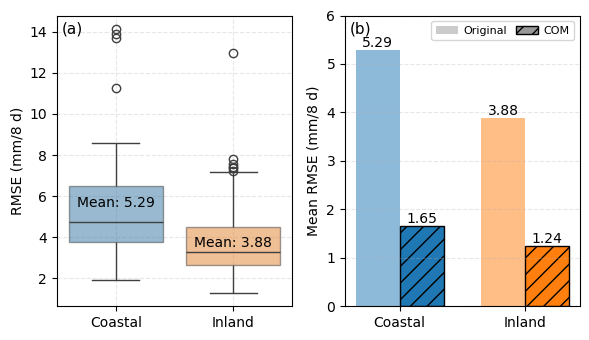

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnchoredText

# === 1. Define station groups ===
COASTAL_STATIONS = ['MC', 'SA', 'BT', 'RP', 'NT', 'MH', 'JC', 'FR', 'VO', 'SI', 'CT']
INLAND_STATIONS = ['AY', 'OP', 'MP', 'BE', 'MR', 'DY', 'GN', 'MD', 'CS', 'CA']
ALL_STATIONS = COASTAL_STATIONS + INLAND_STATIONS

# === 2. Load data ===
STN_ERR = xr.open_dataarray("../DATA/STN_ERR.nc")
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
err_com = xr.open_dataarray("../DATA/STN_COM_ERR.nc")

# Drop unwanted products
if "Product" in STN_ERR.dims:
    STN_ERR = STN_ERR.drop_sel(Product=["PM", "TH"])
if "Product" in STN_DATA.dims:
    STN_DATA = STN_DATA.drop_sel(Product=["PM", "TH"])

# === 3. Compute RMSE ===
rmse_raw = np.sqrt((STN_ERR**2).mean(dim="datetime"))
rmse_com = np.sqrt((err_com**2).mean(dim="datetime"))

# === 4. Filter for station groups ===
coastal_rmse = rmse_raw.sel(Station=COASTAL_STATIONS)
inland_rmse = rmse_raw.sel(Station=INLAND_STATIONS)

# === 5. Compute group means ===
coastal_mean_COM = rmse_com.sel(Station=COASTAL_STATIONS).mean().values
inland_mean_COM = rmse_com.sel(Station=INLAND_STATIONS).mean().values
coastal_mean_RAW = coastal_rmse.mean().values
inland_mean_RAW = inland_rmse.mean().values

# Δ differences
com_diff = coastal_mean_COM - inland_mean_COM
raw_diff = coastal_mean_RAW - inland_mean_RAW

# Prepare bar data
categories = ['Coastal', 'Inland']
com_values = [coastal_mean_COM, inland_mean_COM]
raw_values = [coastal_mean_RAW, inland_mean_RAW]
x = np.arange(len(categories))
width = 0.35

# === 6. Combined figure ===
FONT_SIZE = 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5))

# Panel (a): Boxplot of Coastal vs Inland RMSE
sns.boxplot(data=[coastal_rmse.values.flatten(), inland_rmse.values.flatten()],
            width=0.8, palette=["#1f77b4", "#ff7f0e"], ax=ax1)

# Match the lighter style of the original-product bars in panel (b)
for patch in ax1.patches:
    patch.set_alpha(0.5)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Coastal', 'Inland'], fontsize=FONT_SIZE)
ax1.tick_params(axis='y', labelsize=FONT_SIZE)
ax1.set_ylabel('RMSE (mm/8 d)', fontsize=FONT_SIZE)
ax1.grid(True, alpha=0.3, linestyle='--')

# Add mean annotations
ax1.text(0, coastal_rmse.mean()+0.05, f'Mean: {coastal_rmse.mean().values:.2f}',
         ha='center', va='bottom', fontweight='normal', fontsize=FONT_SIZE)

# Inland annotation moved lower
ax1.text(1, inland_rmse.mean()-0.5, f'Mean: {inland_rmse.mean().values:.2f}',
         ha='center', va='bottom', fontweight='normal', fontsize=FONT_SIZE)

ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes,
         ha='left', va='top', fontweight='normal', fontsize=FONT_SIZE + 1)

# Panel (b): Barplot of Mean RMSE for COM vs RAW
rects_raw = ax2.bar(x - width/2, raw_values, width,
                    color=['#1f77b4', '#ff7f0e'], alpha=0.5)

rects_com = ax2.bar(x + width/2, com_values, width,
                    color=['#1f77b4', '#ff7f0e'],
                    alpha=1.0, hatch='//', edgecolor='black')

# Add value labels
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom',
                fontsize=FONT_SIZE - 0)

add_value_labels(rects_raw, ax2)
add_value_labels(rects_com, ax2)

# Axes and grid
ax2.set_ylabel('Mean RMSE (mm/8 d)', fontsize=FONT_SIZE)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=FONT_SIZE)
ax2.tick_params(axis='y', labelsize=FONT_SIZE)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 6)

# In-figure legend for bar styles
legend_handles = [
    Patch(facecolor='0.6', alpha=0.5, label='Original'),
    Patch(facecolor='0.6', edgecolor='black', hatch='//', label='COM')
]
ax2.legend(handles=legend_handles, loc='upper right', fontsize=8,
           frameon=True, ncol=2, columnspacing=0.8, handletextpad=0.5)

ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes,
         ha='left', va='top', fontweight='normal', fontsize=FONT_SIZE + 1)

plt.tight_layout()
plt.savefig("COASTAL_INLAND.png", dpi=300, bbox_inches='tight')
plt.show()
